*Author: Abdourahmane Diaw (diawa @ornl.gov, Oak Ridge National Laboratory).*  
*Copyright (c) 2023-2026 Oak Ridge National Laboratory.*  
*License: GPL-3.0-or-later. The full license text is available at:*  
*[github.com/diawabdou/OpenEdge/blob/main/LICENSE](https://github.com/diawabdou/OpenEdge/blob/main/LICENSE).*

---


# Temperature-driven Li emission from the CAT outer divertor

This notebook is an end-to-end demo of how OpenEdge consumes a SOLPS-LM MHD code result as a per-surf $T_\mathrm{surf}$ source for atomic and droplet
emission off a liquid-metal divertor target.

The workflow has six pieces — each one is a section below.

| section | what it does | key artifact |
|--|--|--|
| 1 | build the divertor slab geometry inline | `input/divertor_slab.surf` |
| 2 | load $T_\mathrm{surf}(s)$ from the LM MHD model | `T_strip` array on segment midpoints |
| 3 | inspect SOLPS heat flux $W_\mathrm{tot}(s)$ and ion flux $\Gamma_{D^+}(s)$ | `Wtot_strip`, `Gamma_D_strip` |
| 4 | evaluate Li evaporation and adatom desorption fluxes from $T_\mathrm{surf}$ | `G_evap`, `G_adat` |
| 5 | inject $T_\mathrm{surf}$ and $\Gamma_{D^+}$ as per-surf custom columns | `input/divertor_slab_strip.surf` |
| 6 | create a droplet species (sphere of radius $r$ at liquid-metal density $\rho$) | `input/droplet.species` |
| 7 | assemble a complete OpenEdge input deck | `in.tsurf_emission` |

**Two physical processes** appear here, both driven by the same per-surf $T_\mathrm{surf}$ field:

1. **Atomic Li evaporation** — Antoine vapour pressure + Hertz-Knudsen flux. Single Li atoms leaving the surface with a Maxwell-Boltzmann velocity distribution at $T_\mathrm{surf}$. This is what `compute surface/chemical/evaporation` and `compute surface/chemical/adatom` produce.  `fix surface/emit/source` takes the fluxes from the computes and emit Li atoms from the surfaces.  We **don't emiy Li atoms due to droplets evaporation in this deck (commented it out)**
   
3. **Droplet ejection** — much rarer, much heavier macro-particles (a 1 µm droplet contains ~$10^{11}$ Li atoms). 

All plots use the helpers in `plotter.py` (paper-ready: LaTeX labels, units in (), big fonts).


## 0. Imports and physical constants

We mirror the constants used in `src/OPENEDGE/liquid_metal_strip.h` so the Python
preview here is bit-for-bit identical to what the C++ side computes at runtime.


In [119]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import plotter
plotter.use_paper_style()
plotter.bump_notebook_fonts(px=18)

from evap_adatom import li_evap_flux, li_adatom_flux

# General constants used elsewhere (droplet species, etc.)
KB        = 1.380649e-23      # Boltzmann [J/K]
EV        = 1.602176634e-19   # eV -> J
AMU       = 1.66053906660e-27 # kg/amu
PI        = np.pi


## 1. Geometry — the divertor slab, built inline

We model the CAT-like outer divertor target as a thin slab in the $(R, Z)$
plane. Two endpoints define the leading face of the slab:

- `P1 = (3.479, -3.110)` — top of the outer divertor
- `P2 = (3.382, -3.777)` — bottom

We sample `N_ARC = 200` evenly-spaced points along the chord `P1 → P2`. That
gives `n_arc_lines = 199` line segments on the front face. To close the loop
into a watertight surface (so OpenEdge's surface particle-check passes), we add
3 back-cap segments offset by `SLAB_WIDTH = 8 mm` in the $+R$ direction.

Total: 202 points, 202 lines — 199 front-arc + 3 back-cap.

The mesh is written as an OpenEdge `.surf` file `input/divertor_slab.surf`
that `read_surf` can ingest directly.


In [120]:
# corners
P1 = (3.47877407, -3.11049628)   # top of outer divertor
P2 = (3.38162422, -3.77747631)   # bottom

# resolution + back-cap stand-off
N_ARC      = 200                 # points along front face
SLAB_WIDTH = 8.0e-3              # back-cap stand-off in +R [m]

# arc points along P1 -> P2
xs_arc = [P1[0] + (k/(N_ARC-1))*(P2[0]-P1[0]) for k in range(N_ARC)]
ys_arc = [P1[1] + (k/(N_ARC-1))*(P2[1]-P1[1]) for k in range(N_ARC)]

# back-cap points (P2', P1') offset by +SLAB_WIDTH in R
P2_prime = (P2[0] + SLAB_WIDTH, P2[1])
P1_prime = (P1[0] + SLAB_WIDTH, P1[1])

# assemble pts dict + lines list — same shape parse_surf would return
pts = {i+1: (xs_arc[i], ys_arc[i]) for i in range(N_ARC)}
pts[N_ARC + 1] = P2_prime
pts[N_ARC + 2] = P1_prime

lines = []
for k in range(N_ARC - 1):
    lines.append([k+1, k+1, k+2])                 # arc: k -> k+1
lines.append([N_ARC,     N_ARC,     N_ARC + 1])   # cap: P2 -> P2'
lines.append([N_ARC + 1, N_ARC + 1, N_ARC + 2])   # cap: P2' -> P1'
lines.append([N_ARC + 2, N_ARC + 2, 1])           # cap: P1' -> P1

n_arc_lines  = N_ARC - 1
n_total_lines = len(lines)
print(f"divertor slab: {len(pts)} points, {n_total_lines} lines"
      f" (arc {n_arc_lines}, caps 3)")

# write to file so OpenEdge can read_surf it later
out = Path("input/divertor_slab.surf")
out.parent.mkdir(exist_ok=True)
with open(out, "w") as f:
    f.write(f"# inline-built slab, P1={P1}, P2={P2}, slab width {SLAB_WIDTH*1e3:.1f} mm\n\n")
    f.write(f"{len(pts)} points\n{len(lines)} lines\n\nPoints\n\n")
    for pid in sorted(pts):
        x, y = pts[pid]
        f.write(f"{pid} {x:.8f} {y:.8f}\n")
    f.write("\nLines\n\n")
    for lid, p1, p2 in lines:
        f.write(f"{lid} {p1} {p2}\n")
print(f"wrote {out}")


divertor slab: 202 points, 202 lines (arc 199, caps 3)
wrote input/divertor_slab.surf


**Visual check.** Front-arc segments are drawn in steelblue; the 3 back-cap
segments closing the loop are crimson.


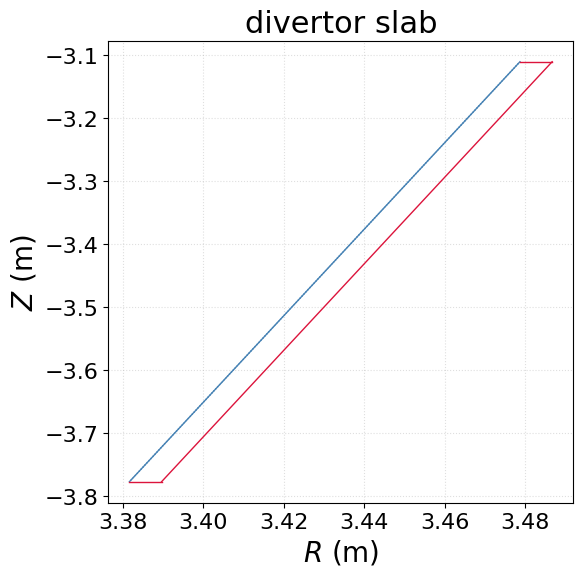

In [121]:
plotter.plot_geometry(pts, lines, n_arc_lines)
plt.show()


## 2. Surface temperature — pre-computed strip CSV → custom .surf columns

This notebook reads a smooth surface-temperature profile from
`input/strip_ol.csv` and bakes it into the `.surf` file as two custom
per-line columns, `Tsurf_lm` and `Gamma_D_lm`. The deck then attaches them
via:

```
read_surf input/divertor_slab_strip.surf custom Tsurf_lm float 0 custom Gamma_D_lm float 0 ...
```

and the OpenEdge atomic-Li source computes consume the customs:

```
compute cevap  surface/chemical/evaporation div_front tsurf Tsurf_lm sticking 1
compute cadat  surface/chemical/adatom      div_front tsurf Tsurf_lm dp_flux s_Gamma_D_lm
compute cpmiLi surface/physical/sputter     div_front background pd target Li ...
```

`strip_ol.csv` itself comes from Smolentsev's free-flowing-film MHD
LM MHD model (Antoine + Hertz–Knudsen evaporation, shallow-water MHD, 1-D
heat transfer). You can regenerate it externally and drop the new file in
`input/` — this notebook treats it as opaque data.

> **Alternative (not used here):** OpenEdge can also solve the LM MHD model
> at runtime via `fix surface/state/lm`. The deck has it commented out;
> uncomment it and switch `read_surf` to plain `divertor_slab.surf` if you
> ever want to drive Tsurf live from `ld_tg_o.dat` instead of a baked CSV.

Before assigning anything per-surf we need an arc-length coordinate $s_i$ for
each front-arc line segment `i`. We use the **midpoint** of each segment:

$$
s_i = \sum_{j<i} \Delta s_j + \tfrac{1}{2} \Delta s_i, \quad \Delta s_j = |P_{j+1}-P_j|
$$

This matches the convention used by `read_surf custom Tsurf_lm float 0`:
**one custom-column value per line segment**.


In [122]:
# Arc-length s_i along the FRONT face: s at the midpoint of each arc line
arc_lines = [ln for ln in lines if ln[0] <= n_arc_lines]
x_mid, y_mid, s_mid = [], [], []
s_acc = 0.0
for lid, p1, p2, *_ in arc_lines:
    x1, y1 = pts[p1]; x2, y2 = pts[p2]
    seg_len = np.hypot(x2-x1, y2-y1)
    s_mid.append(s_acc + 0.5 * seg_len)
    x_mid.append(0.5 * (x1+x2)); y_mid.append(0.5 * (y1+y2))
    s_acc += seg_len
s_mid = np.array(s_mid); x_mid = np.array(x_mid); y_mid = np.array(y_mid)
L_total = s_acc
print(f"arc length total = {L_total:.4f} m, {len(s_mid)} segment midpoints")
print(f"  ds (uniform): {(L_total / n_arc_lines)*1e3:.3f} mm")


arc length total = 0.6740 m, 199 segment midpoints
  ds (uniform): 3.387 mm


### Load `input/strip_ol.csv` and interpolate onto segment midpoints

`strip_ol.csv` is the smooth profile from Smolentsev's LM MHD model, sampled at
$N_x \approx 200$ stations. Columns:

| column | symbol | units |
|--|--|--|
| `s_m` | $s$ | m |
| `R_m`, `Z_m` | $R$, $Z$ | m |
| `Tsurf_C` | $T_\mathrm{surf}$ | °C |
| `h_m` | film thickness | m |
| `Wtot_Wm2` | $W_\mathrm{tot}$ | W m$^{-2}$ |
| `Gamma_D_m2s` | $\Gamma_{D^+}$ | m$^{-2}$ s$^{-1}$ |
| `Gamma_evap_m2s` | $\Gamma_\mathrm{evap}$ (LM MHD model) | m$^{-2}$ s$^{-1}$ |

The CSV's `s_m` axis can run either direction along the divertor depending
on the SOLPS run (P1→P2 or P2→P1). We dodge that by interpolating
**directly in $(R, Z)$**: for each slab segment midpoint we walk along the
CSV's $(R_m, Z_m)$ polyline and pull the value at the projected arc-length.
This is orientation-agnostic — works no matter which way the strip CSV is
oriented.


In [123]:
import pandas as pd

strip_csv = Path("input/strip_ol.csv")
if not strip_csv.exists():
    raise FileNotFoundError(
        f"missing {strip_csv}\n"
        "either run with `fix flm_ol surface/state/lm ... csv output/strip_ol.csv` "
        "and `mv output/strip_ol.csv input/`, or drop a strip CSV here from "
        "your own thermal model."
    )

df = pd.read_csv(strip_csv)
print(f"loaded {strip_csv}: {len(df)} rows x {df.shape[1]} columns\n")
print(df.describe(percentiles=[0.5]).T[["min", "50%", "max"]])

# Build cumulative arc-length along the CSV's (R_m, Z_m) polyline.
csv_R = df["R_m"].values; csv_Z = df["Z_m"].values
csv_arc = np.zeros(len(df))
csv_arc[1:] = np.cumsum(np.hypot(np.diff(csv_R), np.diff(csv_Z)))

# For each slab segment midpoint, find arc length along the CSV polyline
# by projecting onto the closest CSV point. (R, Z) match -> orientation
# of the CSV doesn't matter, the strip values land at the right spot.
def project_to_csv_arc(x, y):
    d2 = (csv_R - x)**2 + (csv_Z - y)**2
    return csv_arc[int(np.argmin(d2))]

slab_to_csv_arc = np.array([project_to_csv_arc(xi, yi)
                            for xi, yi in zip(x_mid, y_mid)])

T_strip       = np.interp(slab_to_csv_arc, csv_arc, df["Tsurf_C"])
Wtot_strip    = np.interp(slab_to_csv_arc, csv_arc, df["Wtot_Wm2"])
Gamma_D_strip = np.interp(slab_to_csv_arc, csv_arc, df["Gamma_D_m2s"])

print(f"\nT_strip peak {T_strip.max():.1f} C at slab s={s_mid[T_strip.argmax()]:.3f} m "
      f"(R={x_mid[T_strip.argmax()]:.3f}, Z={y_mid[T_strip.argmax()]:.3f})")


loaded input/strip_ol.csv: 201 rows x 8 columns

                         min           50%           max
s_m             0.000000e+00  3.434155e-01  6.868310e-01
R_m             3.386100e+00  3.435613e+00  3.502940e+00
Z_m            -3.746910e+00 -3.407077e+00 -3.073040e+00
Tsurf_C         3.500000e+02  4.057767e+02  4.526865e+02
h_m             5.000000e-03  5.212400e-03  5.232933e-03
Wtot_Wm2        1.544710e+04  6.750099e+05  1.416806e+07
Gamma_D_m2s     5.258272e+22  5.240044e+24  3.286362e+25
Gamma_evap_m2s  8.715423e+19  1.040622e+21  6.221168e+21

T_strip peak 452.7 C at slab s=0.449 m (R=3.414, Z=-3.555)


<Axes: title={'center': 'LM MHD model surface temperature along outer divertor'}, xlabel='arc length $s$ (m)', ylabel='$T_\\mathrm{surf}$ ($^\\circ$C)'>

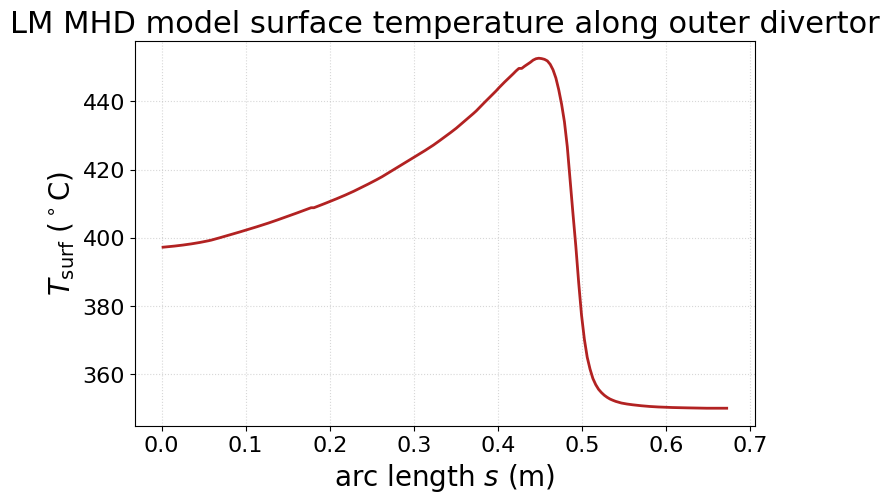

In [124]:
plotter.plot_tsurf_profile(s_mid, T_strip)


## 3. SOLPS plasma background

The deck needs a plasma to drive droplet charging, drag, and (optionally)
the surface heat flux that sets $T_\mathrm{surf}$. We get it by feeding
a SOLPS run through `tools/converters/convert_solps_plasma.py`, which
writes a single `plasma.h5` containing $n_e$, $T_e$, $T_i$, $u_\parallel$,
$\nabla T_e$, $\nabla T_i$, $E_\parallel$, $B_R$, $B_t$, $B_Z$, plus
per-cell wall heat flux on the unstructured SOLPS mesh and the GEQDSK
equilibrium $\psi(R,Z)$.

Run the converter once (skip if you already have an `input/plasma.h5`):

```python
import sys, subprocess
subprocess.run([
    sys.executable,
    "../../tools/converters/convert_solps_plasma.py",
    "/path/to/SOLPS_run",
    "--equ-file", "/path/to/g000001.00001_symm.X4.equ",
    "--plasma-out", "input/plasma.h5",
], check=True)
```
**Two ways to turn the wall heat flux into $T_\mathrm{surf}$:**

1. *External* — run the LM MHD model on the SOLPS heat flux,
   write a CSV of $T_\mathrm{surf}(s)$, read it back here (this is what
   §2 already does).
2. *Internal* — drop the CSV and let `fix surface/state/lm` evolve the LM
   strip inside the deck. Same physics, no preprocessing step.


groups: ['b2', 'equilibrium', 'fort31', 'ion_species', 'mesh', 'wall_flux']
mesh fields: ['cell_index', 'dens_e', 'dens_i', 'e_r', 'e_t', 'e_z', 'grad_te_r', 'grad_te_z', 'grad_ti_r', 'grad_ti_z', 'ions', 'parr_flow', 'pob', 'rrb']


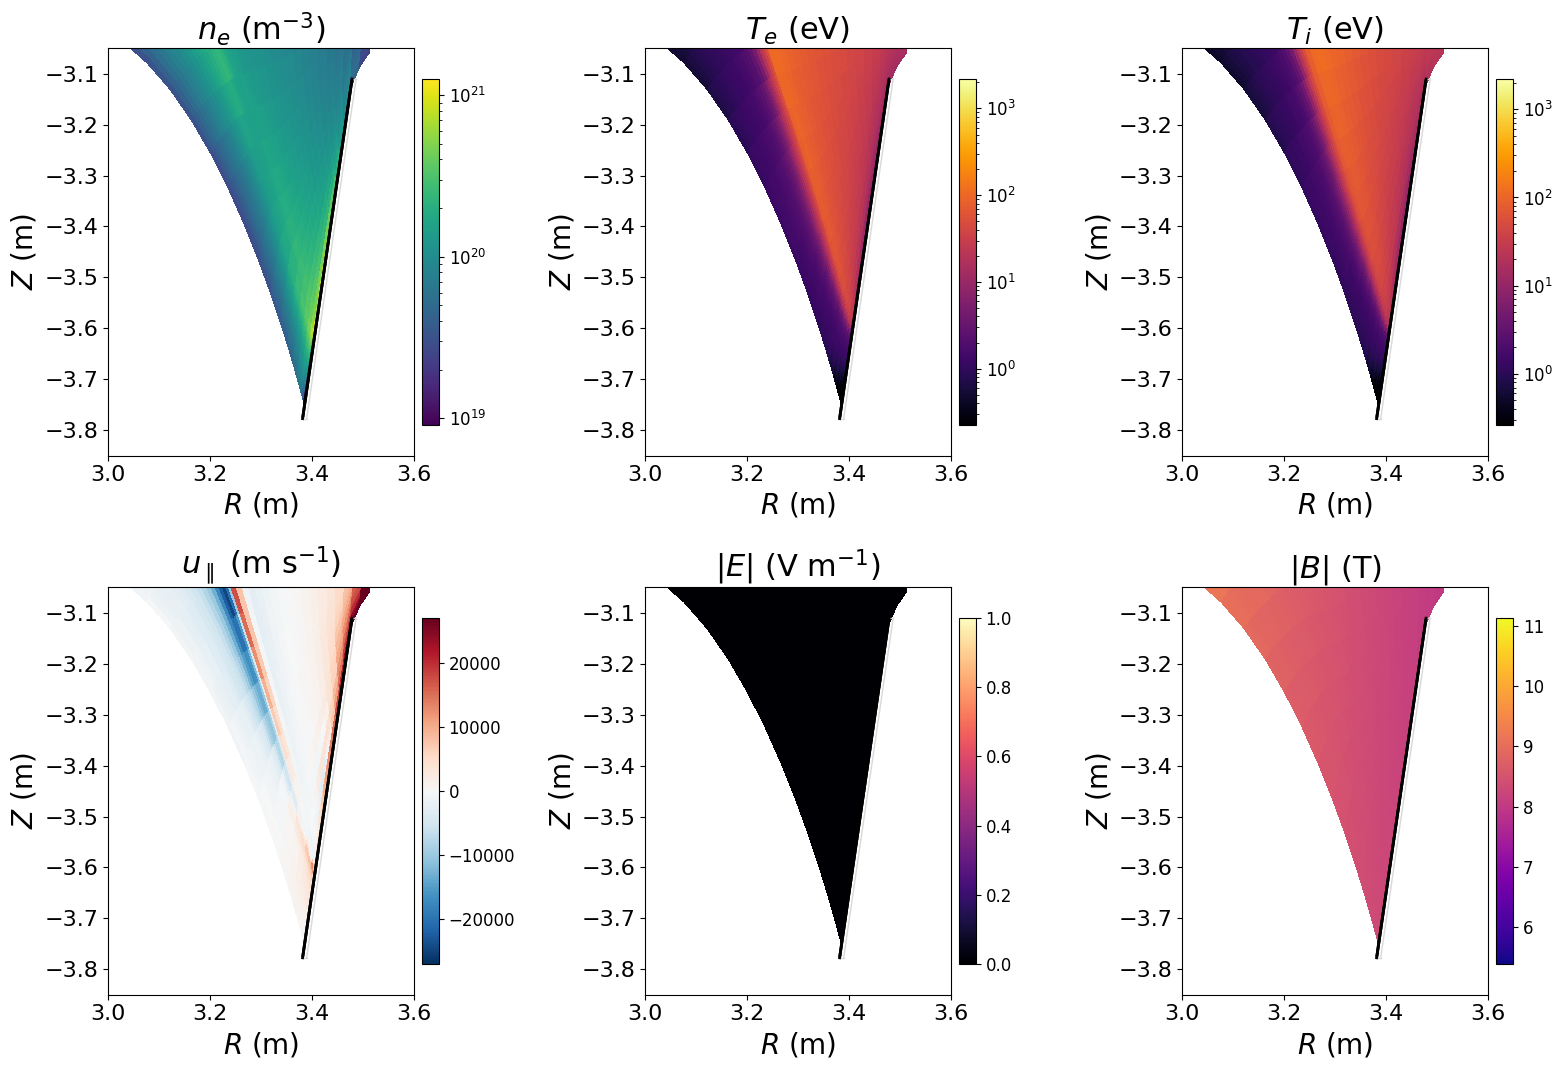

In [125]:
import h5py
with h5py.File("input/plasma.h5", "r") as f:
    print("groups:", list(f.keys()))
    print("mesh fields:", [k for k in f["mesh"].keys()][:14])

# Six-panel quicklook (ne, Te, Ti, u_par, |E|, |B|), with psi contours and
# the divertor slab overlaid. Crop to the divertor region.
plotter.plot_plasma_h5_b2(
    "input/plasma.h5",
    pts=pts, lines=lines, n_arc_lines=n_arc_lines,
    zoom=(3.0, 3.6, -3.85, -3.05),
)
plt.show()


**Along-divertor profiles** from the LM MHD model CSV (used in §2 to set
$T_\mathrm{surf}$ and $\Gamma_{D^+}$):


(<Figure size 1300x500 with 2 Axes>,
 array([<Axes: title={'center': 'SOLPS total heat flux'}, xlabel='arc length $s$ (m)', ylabel='$W_\\mathrm{tot}$ (MW m$^{-2}$)'>,
        <Axes: title={'center': 'SOLPS D$^+$ ion flux to target'}, xlabel='arc length $s$ (m)', ylabel='$\\Gamma_{D^+}$ (m$^{-2}$ s$^{-1}$)'>],
       dtype=object))

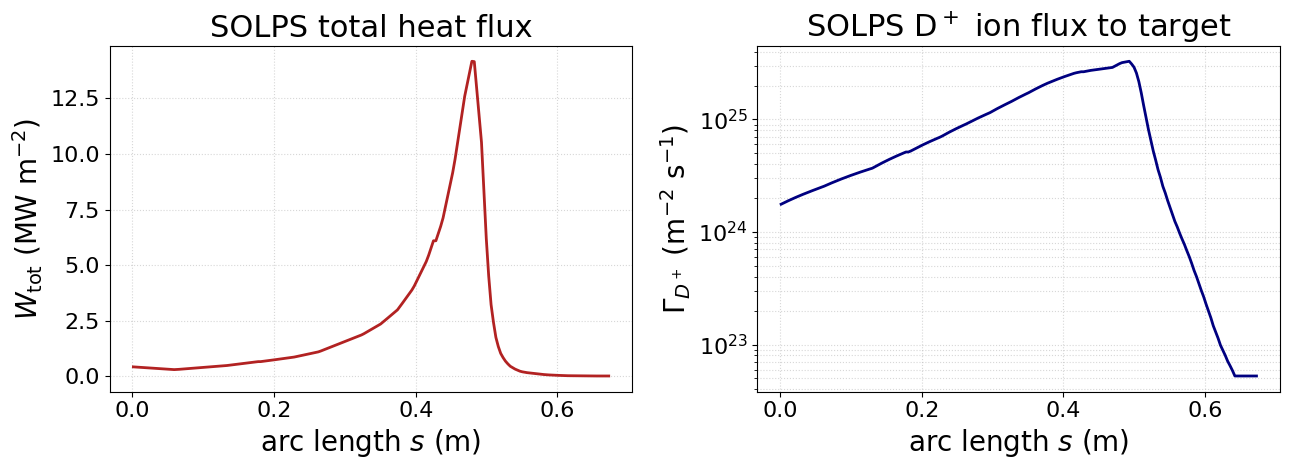

In [126]:
plotter.plot_solps_profiles(s_mid, Wtot_strip, Gamma_D_strip)


**Surface temperature mapped onto the actual wall geometry** (front face in
color, back caps in grey):


(<Figure size 1000x600 with 2 Axes>,
 <Axes: title={'center': 'Surface Temperature'}, xlabel='$R$ (m)', ylabel='$Z$ (m)'>)

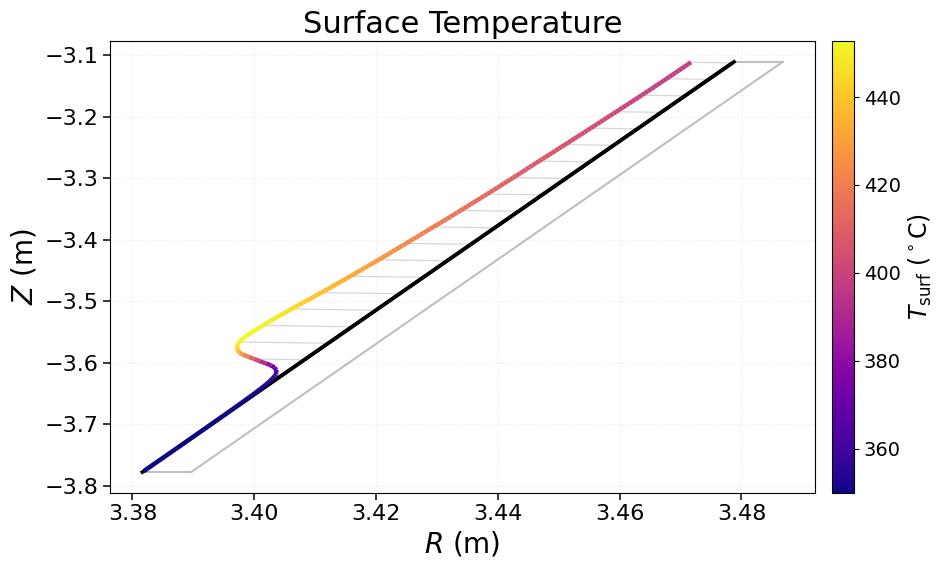

In [127]:
plotter.plot_tsurf_on_wall(pts, lines, n_arc_lines, x_mid, y_mid, T_strip)


## 4. Resulting Li atomic flux: evaporation + adatom desorption

Apply the Antoine + Hertz–Knudsen evaporation flux to the interpolated
$T_\mathrm{surf}(s)$ profile:


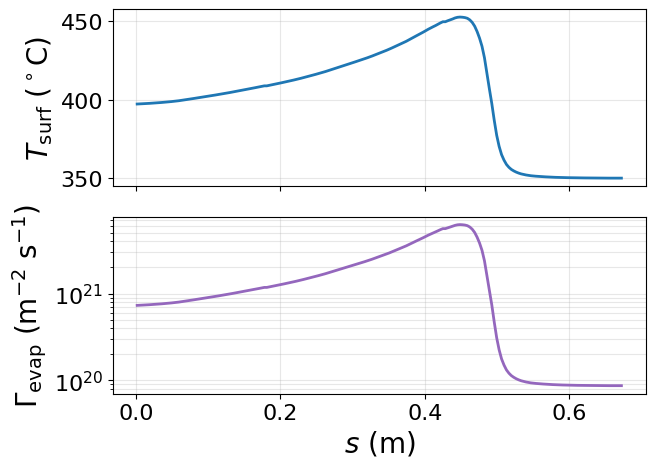

In [128]:
G_evap = li_evap_flux(T_strip)

fig, axes = plt.subplots(2, 1, figsize=(7, 5), sharex=True)
axes[0].plot(s_mid, T_strip, lw=2)
axes[0].set_ylabel(r"$T_\mathrm{surf}$ ($^\circ$C)")
axes[0].grid(True, alpha=0.3)
axes[1].semilogy(s_mid, G_evap, lw=2, color="C4")
axes[1].set_ylabel(r"$\Gamma_\mathrm{evap}$ (m$^{-2}$ s$^{-1}$)")
axes[1].set_xlabel(r"$s$ (m)")
axes[1].grid(True, which="both", alpha=0.3)
plt.tight_layout(); plt.show()


**Total atomic Li flux mapped onto the wall** (log-color):


(<Figure size 1000x600 with 2 Axes>,
 <Axes: title={'center': 'Total Eroded Flux'}, xlabel='$R$ (m)', ylabel='$Z$ (m)'>)

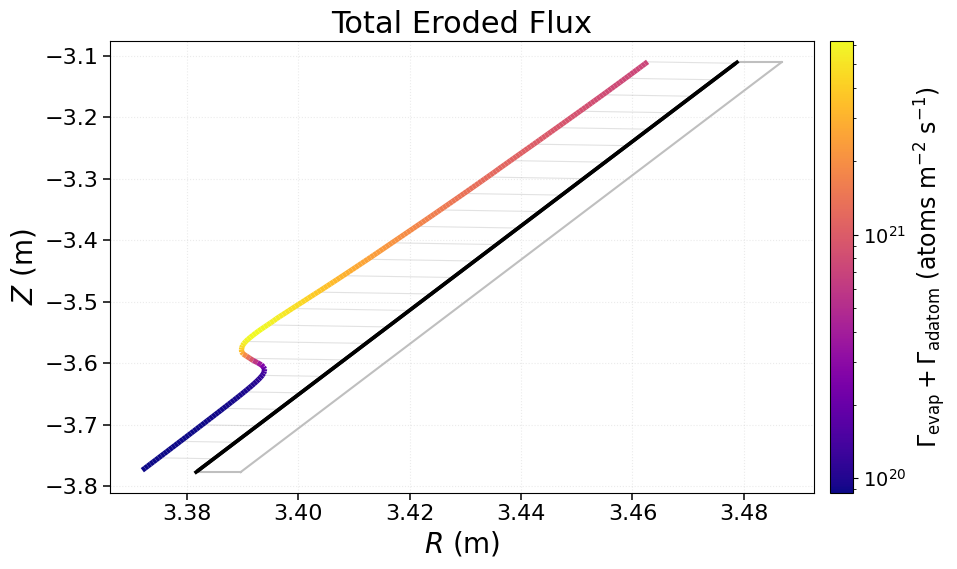

In [129]:
plotter.plot_total_flux_on_wall(pts, lines, n_arc_lines,
                                x_mid, y_mid, G_evap, np.zeros_like(G_evap))


## 5. Attach $T_\mathrm{surf}$ and $\Gamma_{D^+}$ to the wall

We already have `T_strip` and `Gamma_D_strip` from §2 (interpolated from
`input/strip_ol.csv` onto the 199 front-arc segment midpoints). All that's
left is to **append them as two custom columns on every Lines row** of the
`.surf` file. No regeneration — just attach existing data.

The deck reads them via:

```
read_surf input/divertor_slab_strip.surf custom Tsurf_lm float 0 custom Gamma_D_lm float 0 ...
```

Back-cap rows get zeros (they're not in the `div_front` group, so they
never emit).


In [130]:
src  = Path("input/divertor_slab.surf")        # geometry only
dst  = Path("input/divertor_slab_strip.surf")  # geometry + Tsurf_lm + Gamma_D_lm

with src.open() as f, dst.open("w") as g:
    g.write("# divertor_slab.surf with Tsurf_lm [degC] and Gamma_D_lm [m^-2 s^-1] columns\n")
    g.write(f"# n_arc={n_arc_lines}, back-cap rows zero in both columns\n\n")
    in_lines = False
    for raw in f:
        s = raw.strip()
        if s.lower().startswith("lines"):
            in_lines = True; g.write(raw); continue
        if not in_lines or not s or not s[0].isdigit():
            g.write(raw); continue
        lid, p1, p2 = s.split()[:3]
        lid = int(lid)
        if lid <= n_arc_lines:
            T = float(T_strip[lid - 1]); G = float(Gamma_D_strip[lid - 1])
        else:
            T, G = 0.0, 0.0
        g.write(f"{lid} {p1} {p2} {T:.6e} {G:.6e}\n")

print(f"wrote {dst}")
print(f"  Tsurf peak     {T_strip.max():7.1f} C    at s={s_mid[T_strip.argmax()]:.3f} m")
print(f"  Gamma_D peak   {Gamma_D_strip.max():.2e}  at s={s_mid[Gamma_D_strip.argmax()]:.3f} m")


wrote input/divertor_slab_strip.surf
  Tsurf peak       452.7 C    at s=0.449 m
  Gamma_D peak   3.29e+25  at s=0.493 m


## 6. Create a droplet species

In addition to atomic Li emission (sections 4–5), liquid-metal divertor
targets can shed **droplets**: macroscopic spheres of liquid Li ejected from the
free surface by capillary instabilities, Kelvin-Helmoltz, perhaps pellet impact, or ELM.

In OpenEdge / OpenEdge, a droplet is **one macro-particle** carrying the mass of
a sphere of bulk-liquid metal. To declare such as particle we need a `.species`
file. Format (tabs or whitespace separated):

```
ID  Molwt(amu)  Molmass(kg)  RotDof  RotRel  VibDof  VibRel  VibTemp(K)  specwt  charge  radius(m)  temp(K)
```

The 12 fields are:

| field | what it is | typical value for a Li droplet |
|--|--|--|
| `ID` | species name used in `mixture` and elsewhere | e.g. `Lid` |
| `Molwt(amu)` | molecular weight in atomic mass units | $m / m_u \sim 10^{12}$ for 1 µm |
| `Molmass(kg)` | mass in kg | $\tfrac{4}{3}\pi r^3 \rho$ |
| `RotDof`, `RotRel` | rotational DOFs and relaxation collisions | **0** (rigid sphere; non-zero if you want to track rotation) |
| `VibDof`, `VibRel`, `VibTemp(K)` | vibrational DOFs / collisions / characteristic temp | **0** (no internal modes; non-zero for breathing modes) |
| `specwt` | how many real droplets one OpenEdge particle represents | typically **1.0** for droplet runs (each macro-particle = one real droplet) |
| `charge` | initial charge in elementary units | **0** (set by `fix droplet/charge` during the run via OML/sheath) |
| `radius(m)` | physical radius (consumed by `fix drag`, `fix droplet/charge`, etc.) | user input |
| `temp(K)` | initial droplet temperature | typically $T_\mathrm{surf}$ at the launch point or a global value |

**Why mass = $\tfrac{4}{3}\pi r^3 \rho$**: a droplet is a sphere of liquid
metal. For Li at the divertor operating point ($T \sim 500$ K, just above the
melting point at 453.7 K) the bulk density is $\rho \approx 530$ kg/m$^3$.
For Sn it's $\rho \approx 6900$ kg/m$^3$, etc.

**Defaults set to zero, with a note**: for a first-cut deck we don't track
internal rotational or vibrational DOFs of the droplet — set them to 0. If
later you want to model droplet spin-up or breathing modes (well I do not understand this physics so not going this direction for now), you can set
`RotDof = 3` (a rigid 3D body has 3 rotational DOFs) and provide a relaxation
number. Same for vibrational — `VibDof / VibRel / VibTemp` would be a
characteristic single-mode oscillator. The `create_droplet_species` function
below makes all of these keyword arguments so you can override them.

Format reference: `examples/test_droplet/droplet.species` and
`examples/test_solps_coupling/input/droplet.species` follow the same
12-field convention.


In [131]:
def create_droplet_species(
    out_path,
    name,
    radius_m,
    rho_kg_m3,
    temp_K,
    *,
    rotdof=0,    rotrel=0.0,
    vibdof=0,    vibrel=0.0,    vibtemp_K=0.0,
    specwt=1.0,
    charge=0.0,
    append=False,
):
    """Compute droplet mass from radius + bulk density and write a .species line.

    A droplet is a sphere of bulk liquid metal of radius `radius_m` and
    density `rho_kg_m3`. Mass:

        m = (4/3) * pi * r^3 * rho        [kg]
        molwt = m / m_u                   [amu]    # m_u = 1 amu in kg

    Other fields default to zero (rigid macro-particle, no internal modes,
    initially neutral). Override them via keyword arguments if you want to
    track rotation, vibration, weighted statistics, or non-zero initial
    charge.

    If `append=True`, append the line to an existing file (header is not
    re-written). Useful for building a multi-radius droplet species file.
    """
    AMU = 1.66053906660e-27   # kg/amu
    mass_kg   = (4.0 / 3.0) * PI * radius_m**3 * rho_kg_m3
    molwt_amu = mass_kg / AMU

    header = (
        "# Species data\n"
        "# ID    Molwt(amu)             Molmass(kg)            "
        "RotDof RotRel VibDof VibRel VibTemp(K) specwt charge radius(m) temp(K)\n"
    )
    line = (
        f"{name:<12s} {molwt_amu:.15e} {mass_kg:.15e} "
        f"{rotdof} {rotrel:g} {vibdof} {vibrel:g} {vibtemp_K:g} "
        f"{specwt:g} {charge:g} {radius_m:g} {temp_K:g}\n"
    )

    mode = "a" if append else "w"
    with open(out_path, mode) as f:
        if not append:
            f.write(header)
            f.write(f"# auto-generated by create_droplet_species(): "
                    f"r={radius_m*1e6:.2f} um, rho={rho_kg_m3:g} kg/m^3, T={temp_K:g} K\n")
            f.write(f"# RotDof/VibDof/VibTemp default to 0 (rigid sphere, no internal modes); "
                    f"override via kwargs if you want internal-energy DOFs\n")
            f.write(f"# charge=0 initially; fix droplet/charge updates it during the run\n")
        f.write(line)
    print(f"{'appended' if append else 'wrote'} {out_path}: "
          f"{name} r={radius_m*1e6:.3f} um -> m={mass_kg:.3e} kg ({molwt_amu:.3e} amu)")
    return mass_kg, molwt_amu



# Create a single 50 um Li droplet at liquid-Li density (~530 kg/m^3 above T_melt)
RHO_LI_LIQUID = 530.0   # kg/m^3, liquid Li at ~ 500 K
T_DROPLET_K   = 773.15  # K, typical surface temp during a Li-divertor pulse
RADIUS_M      = 2.5e-3 #50.0e-6  # 1 micron

create_droplet_species(
    "input/droplet.species",
    name="droplet",
    radius_m=RADIUS_M,
    rho_kg_m3=RHO_LI_LIQUID,
    temp_K=T_DROPLET_K,
)


wrote input/droplet.species: droplet r=2500.000 um -> m=3.469e-05 kg (2.089e+22 amu)


(3.4688418883387304e-05, 2.088985413297912e+22)

## 7. The OpenEdge input deck

The deck lives at `in.tsurf_emission`. Open it side-by-side; the key blocks are:

- `variable lm_*` — strip parameters (used by Method A only).
- `read_surf input/divertor_slab_strip.surf custom Tsurf_lm float 0 custom Gamma_D_lm float 0`
  — Method B: the customs we just wrote in §5.
- `fix pd background file input/plasma.h5 static yes` — SOLPS plasma.
- `fix flm_ol surface/state/lm ...` — Method A (commented out by default).
  Switch to it by uncommenting and changing `read_surf` back to the plain
  `divertor_slab.surf`.
- `compute cevap / cadat / cpmiLi` — atomic Li source computes; same for
  both methods.
- `dump dsurf` — per-segment fluxes + the `Tsurf_lm`/`Gamma_D_lm` customs
  every 100 steps.


In [132]:
from pathlib import Path
deck_text = Path("in.tsurf_emission").read_text()
print(deck_text)


shell       mkdir output

seed        12345
dimension   2
boundary    o o p
global      gridcut 0.0 comm/sort no
global      fnum 1e+14
timestep    5e-05

create_box  3.1 3.5 -3.8 -3.1 -0.05 0.05
create_grid 100 100 1
balance_grid rcb cell

species     input/droplet.species droplet
mixture     droplet droplet frac 1.0 nrho 1.0e19 temp 300.0 vstream 0.0 0.0 0.0

read_surf   input/divertor_slab_strip.surf custom Tsurf_lm float 0 custom Gamma_D_lm float 0 &
            invert group slab particle check
group div_front surf id <> 1 199
group div_back  surf id <> 200 202

surf_collide vac specular
surf_modify  slab collide vac

# plasma background from SOLPS-derived plasma.h5
fix pd background file input/plasma.h5 static yes

# Alternate: solve Tsurf at runtime (use divertor_slab.surf for read_surf).
#fix flm_ol surface/state/lm div_front 1 solps_b2pl input/ld_tg_o.dat &
#           h0 5.0e-3 U0 8.0 Bs 5.0 alpha 43.0 width 1.67 Tin 350.0 static yes csv output/strip_ol.csv

compute cevap  sur

## 8. Run

From this directory:

```bash
mpirun -np 4 /home/cloud/buildOpenEdge/src/spa_mpi -in in.tsurf_emission
```

What to look for in the output:

- `f_femit_ev[1]` / `f_femit_ad[1]` — particles launched on **this step** by
  each emit fix. With `nsteps=1, nevery=1, fnum=1.0`, this should equal
  `round(sum_i Gamma_i * area_i * dt)` in real-particle units (they print as
  OpenEdge particle counts; with `fnum=1.0` they coincide).
- `f_femit_ev[2]` / `f_femit_ad[2]` — cumulative totals across the run.
- `np` — running particle count.

A 1-step smoke test will usually launch a few hundred particles (the slab
has 199 segments and the peak fluxes from section 4 are ~$10^{17}$ /m²/s; with
`area_i ~ ds * 1 m / radian * dphi = 1.7e-3 * 1 m * 1 rad = 1.7e-3 m²` for
the 2D-axisymmetric reduction, `Gamma * area * dt ~ 10^{17} * 1.7e-3 * 5e-7
~ 100` per step at the strike point). If you see zero, check:

1. The custom-column attachment — `Tsurf_lm` and `Gamma_D_lm` should appear
   in the surf-attribute list when OpenEdge prints `read_surf` output.
2. `compute cevap` / `compute cadat` should have a per-surf vector after
   `init`.
3. The flux at the segment in question should be > 0 (the back-cap segments
   are zero by construction).


In [133]:
!pwd

/Users/42d/OpenEdge/examples/test_tsurf_emission


In [134]:
%ls

evap_adatom.py     input/             output/            walkthrough.ipynb
in.tsurf_emission  log.openedge       plotter.py


In [136]:
!mpirun -np 4 /Users/42d/OpenEdge/build/src/spa_mac_mpi -in in.tsurf_emission

SPARTA-OPENDGE (20 Jan 2025)
Running on 4 MPI task(s)
Created orthogonal box = (3.1 -3.8 -0.05) to (3.5 -3.1 0.05)
Created 10000 child grid cells
  CPU time = 0.000215 secs
  create/ghost percent = 84.6512 15.3488
Balance grid migrated 7500 cells
  CPU time = 0.009257 secs
  reassign/sort/migrate/ghost percent = 46.1056 0.0972237 32.786 21.0111
Reading surface file ...
  202 lines
  3.38162 3.48677 xlo xhi
  -3.77748 -3.1105 ylo yhi
  0 0 zlo zhi
  0.00338702 min line length
  242 0 = cells overlapping surfs, overlap cells with unmarked corner pts
  9688 70 242 = cells outside/inside/overlapping surfs
  242 = surf cells with 1,2,etc splits
  0.274664159760001 0.27466415976 = cell-wise and global flow volume
  CPU time = 0.004287 secs
  read/check/sort/surf2grid/ghost/inout/particle percent = 45.3231 3.5456 0.723116 45.9062 4.50198 3.40564 0
  surf2grid time = 0.001968 secs
  map/comm1/comm2/comm3/comm4/split percent = 5.33537 3.86179 5.33537 0.50813 0.965447 4.87805
0 = initial surface

## 8b. Post-run: along-strip profile (Method A) or sanity check (Method B)

If you ran with **Method A**, `output/strip_ol.csv` is freshly produced by
`fix flm_ol`. If you ran with **Method B**, it's the input we already loaded
in §2. Either way the schema is the same, so this cell renders the strip
profile that drove the simulation.


input/strip_ol.csv: 201 rows  cols=['s_m', 'R_m', 'Z_m', 'Tsurf_C', 'h_m', 'Wtot_Wm2', 'Gamma_D_m2s', 'Gamma_evap_m2s']
                         min           50%           max
s_m             0.000000e+00  3.434155e-01  6.868310e-01
R_m             3.386100e+00  3.435613e+00  3.502940e+00
Z_m            -3.746910e+00 -3.407077e+00 -3.073040e+00
Tsurf_C         3.500000e+02  4.057767e+02  4.526865e+02
h_m             5.000000e-03  5.212400e-03  5.232933e-03
Wtot_Wm2        1.544710e+04  6.750099e+05  1.416806e+07
Gamma_D_m2s     5.258272e+22  5.240044e+24  3.286362e+25
Gamma_evap_m2s  8.715423e+19  1.040622e+21  6.221168e+21


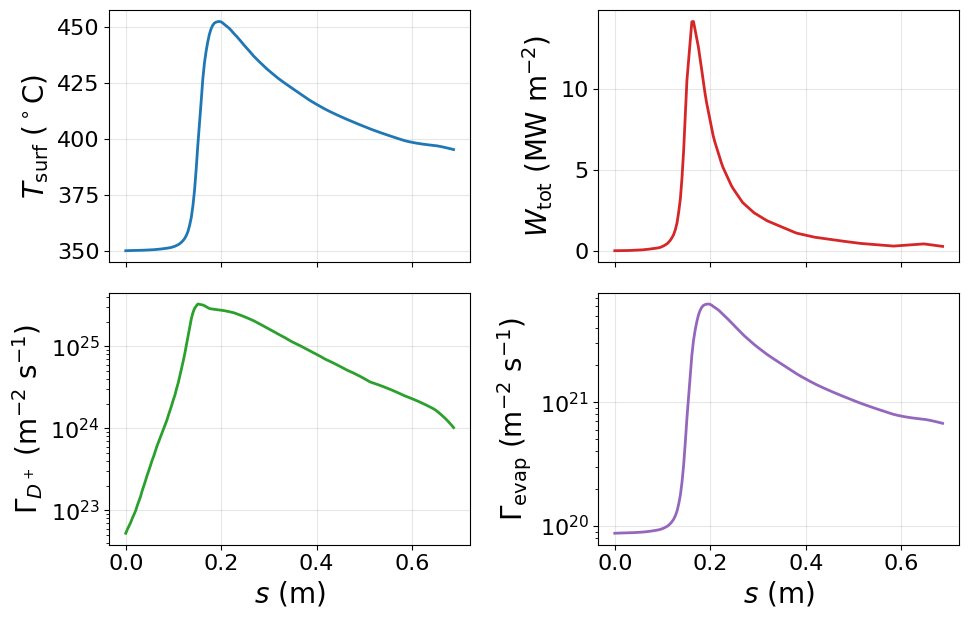

In [137]:
import pandas as pd

# Prefer the runtime dump if Method A was active; fall back to the input CSV.
out = Path("output/strip_ol.csv")
inp = Path("input/strip_ol.csv")
strip_csv = out if out.exists() and out.stat().st_size > 0 else inp
df = pd.read_csv(strip_csv)
print(f"{strip_csv}: {len(df)} rows  cols={list(df.columns)}")
print(df.describe(percentiles=[0.5]).T[["min", "50%", "max"]])

fig, axes = plt.subplots(2, 2, figsize=(10, 6.5), sharex=True)
axes[0,0].plot(df["s_m"], df["Tsurf_C"], lw=2)
axes[0,0].set_ylabel(r"$T_\mathrm{surf}$ ($^\circ$C)")
axes[0,1].plot(df["s_m"], df["Wtot_Wm2"]*1e-6, lw=2, color="C3")
axes[0,1].set_ylabel(r"$W_\mathrm{tot}$ (MW m$^{-2}$)")
axes[1,0].semilogy(df["s_m"], df["Gamma_D_m2s"], lw=2, color="C2")
axes[1,0].set_ylabel(r"$\Gamma_{D^+}$ (m$^{-2}$ s$^{-1}$)")
axes[1,0].set_xlabel(r"$s$ (m)")
axes[1,1].semilogy(df["s_m"], df["Gamma_evap_m2s"], lw=2, color="C4")
axes[1,1].set_ylabel(r"$\Gamma_\mathrm{evap}$ (m$^{-2}$ s$^{-1}$)")
axes[1,1].set_xlabel(r"$s$ (m)")
for ax in axes.flat: ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


## 9. Droplet trajectories

Read the per-step `dump.txt`, group rows by particle id into trajectories,
and overlay them on the divertor slab. Color = `radius` (shrinkage from
evaporation) or `temp` (heating); marker size = current droplet radius.


19 unique droplets, columns: ['id', 'type', 'x', 'y', 'z', 'vx', 'vy', 'vz', 'radius', 'temp']


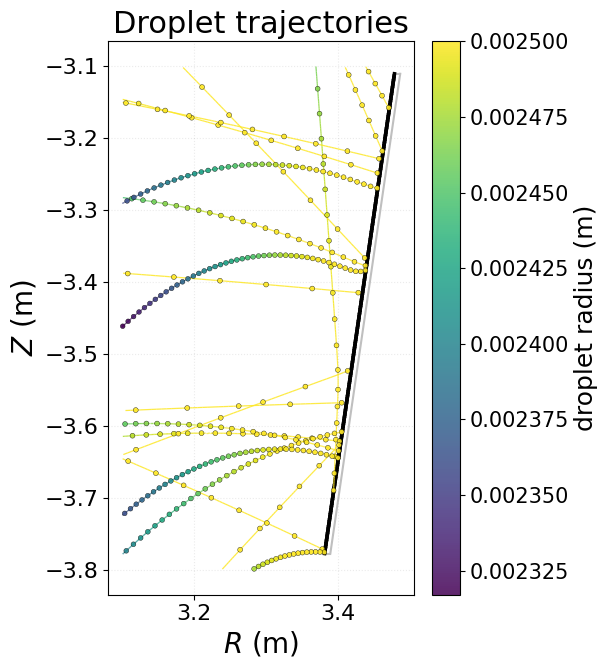

In [138]:
import importlib
importlib.reload(plotter)
cols, trajs = plotter.read_trajectories("output/dump.txt")
print(f"{len(trajs)} unique droplets, columns: {cols}")

fig, ax = plotter.plot_trajectories_on_wall(
    pts, lines, n_arc_lines, trajs,
    color_by="radius",   # try "temp" too
    dot_every=10,
    dot_scale=5e3,
)
plt.show()


## Appendix — files this notebook produces

| path | written by | format |
|--|--|--|
| `input/divertor_slab.surf` | section 1 | OpenEdge `.surf`, no custom columns |
| `input/divertor_slab_strip.surf` | section 5 | OpenEdge `.surf` with `Tsurf_lm` + `Gamma_D_lm` |
| `input/droplet.species` | section 6 | OpenEdge `.species`, droplet macro-particle |
| `in.tsurf_emission` | section 7 | complete OpenEdge input deck |

And reads:

| path | source |
|--|--|
| `input/strip_ol.csv` | LM MHD model (`fix surface/state/lm ... csv`) |
| `input/li.species` | atomic Li species; copied from `examples/test_constant_flux/input/` |
| `plotter.py` | local plotting helpers |


## 11. OpenEdge runtime sputter vs cevap, cadat

Reads the time-averaged per-segment fluxes from `output/surf_flux.*` and
plots them on a shared semilog axis:

- `c_cevap`     — Li atomic-evaporation flux  (Antoine + Hertz–Knudsen of $T_\mathrm{surf}$)
- `c_cadat`     — Li adatom-desorption flux   (Arrhenius of $T_\mathrm{surf}$, scaled by $\Gamma_{D^+}$)
- `c_cpmiLi[1]` — total physical sputter flux (sum over all projectile species)


199 segments, snapshots time-averaged
  $\Gamma_\mathrm{evap}$              peak 6.22e+21 m^-2 s^-1
  $\Gamma_\mathrm{adatom}$            peak 2.49e+22 m^-2 s^-1
  $\Gamma_\mathrm{sput}$ (total)      peak 1.37e+23 m^-2 s^-1


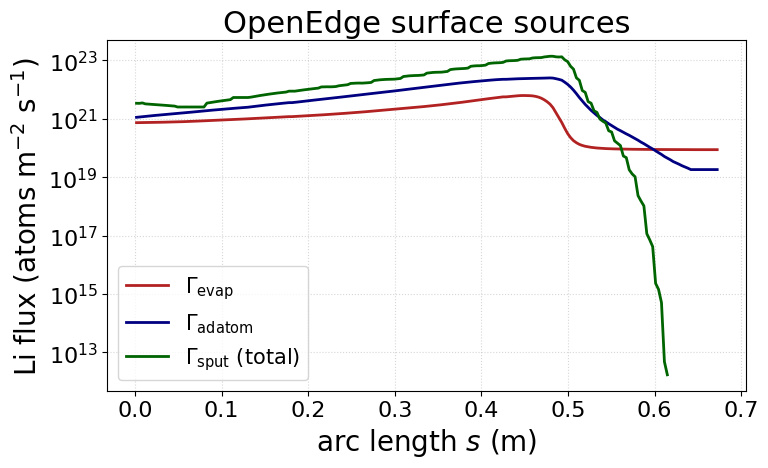

In [139]:
import importlib; importlib.reload(plotter)

sids, data = plotter.read_surf_flux(
    "output/surf_flux.*",
    columns=("c_cevap", "c_cadat", "c_cpmiLi[1]",
             "c_cpmiLi[2]", "c_cpmiLi[3]", "c_cpmiLi[4]", "c_cpmiLi[5]",
             "c_cpmiLi[6]", "c_cpmiLi[7]", "c_cpmiLi[8]", "c_cpmiLi[9]",
             "c_cpmiLi[10]", "c_cpmiLi[11]", "c_cpmiLi[12]",
             "c_cpmiLi[13]", "c_cpmiLi[14]", "c_cpmiLi[15]"),
)
print(f"{len(sids)} segments, snapshots time-averaged")
s_seg = s_mid[sids - 1]

fluxes = {}
if "c_cevap"     in data: fluxes[r"$\Gamma_\mathrm{evap}$"]    = data["c_cevap"]
if "c_cadat"     in data: fluxes[r"$\Gamma_\mathrm{adatom}$"]  = data["c_cadat"]
if "c_cpmiLi[1]" in data: fluxes[r"$\Gamma_\mathrm{sput}$ (total)"] = data["c_cpmiLi[1]"]

for label, f in fluxes.items():
    print(f"  {label:<35s} peak {np.nanmax(f):.2e} m^-2 s^-1")

plotter.plot_oedge_fluxes_1d(s_seg, fluxes)
plt.tight_layout(); plt.show()


## 11c. Sputter per-projectile-species

The runtime compute breaks `c_cpmiLi[1]` (total) into per-species contributions:

| col | species | plasma slot |
|---|---|---|
| `c_cpmiLi[2]` | D⁺ | 0 |
| `c_cpmiLi[3]` | Ne⁺ | 1 |
| `c_cpmiLi[4]` | Ne²⁺ | 2 |
| `c_cpmiLi[5]` | Ne³⁺ | 3 |
| `c_cpmiLi[6..12]` | Ne⁴⁺..Ne¹⁰⁺ | 4..10 |
| `c_cpmiLi[13]` | Li⁺ | 11 |
| `c_cpmiLi[14]` | Li²⁺ | 12 |
| `c_cpmiLi[15]` | Li³⁺ | 13 |

Each line shows where that species contributes to the integrated wall
erosion. D⁺ dominates by orders of magnitude in this CAT case (Ne and Li
fluxes are tracer-level at the outer divertor). A higher-Ne plasma
background will lift those lines off the floor.


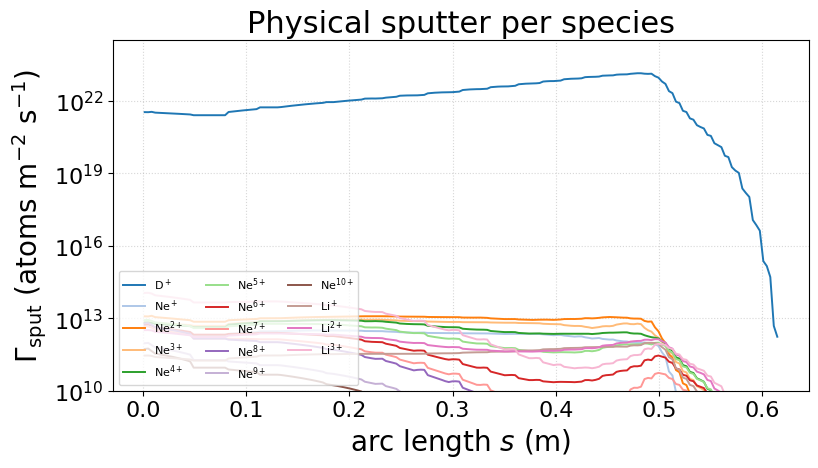

In [140]:
species_labels = ["D$^+$",
                  "Ne$^+$",  "Ne$^{2+}$", "Ne$^{3+}$",
                  "Ne$^{4+}$", "Ne$^{5+}$", "Ne$^{6+}$",
                  "Ne$^{7+}$", "Ne$^{8+}$", "Ne$^{9+}$", "Ne$^{10+}$",
                  "Li$^+$",  "Li$^{2+}$", "Li$^{3+}$"]
# c_cpmiLi[2..15] -> species 0..13
species_cols = [f"c_cpmiLi[{i+2}]" for i in range(14)]

fig, ax = plt.subplots(figsize=(8.5, 5.0))
order = np.argsort(s_seg)
import matplotlib as mpl
cmap = mpl.colormaps['tab20']
for i, (col, lbl) in enumerate(zip(species_cols, species_labels)):
    if col not in data: continue
    f = data[col][order]
    if np.nanmax(f) <= 0: continue
    ax.semilogy(s_seg[order], np.where(f>0, f, np.nan),
                "-", lw=1.4, color=cmap(i), label=lbl)

# # total on top in black for context
# if "c_cpmiLi[1]" in data:
#     f = data["c_cpmiLi[1]"][order]
#     ax.semilogy(s_seg[order], np.where(f>0, f, np.nan),
#                 "-", lw=2.5, color="black", label="total")
ax.set_xlabel(r"arc length $s$ (m)")
ax.set_ylabel(r"$\Gamma_\mathrm{sput}$ (atoms m$^{-2}$ s$^{-1}$)")
ax.set_title("Physical sputter per species")
ax.set_ylim(bottom=1e10)
ax.grid(True, which="both", ls=":", alpha=0.5)
ax.legend(loc="lower left", ncol=3, fontsize=8)
plt.tight_layout(); plt.show()


## 12. Cumulative Li atoms lost from droplet evaporation

`fix droplet/evaporate` exposes a global scalar `f_fevap` — the running
sum of **real Li atoms** evaporated off every droplet on every step,
reduced across MPI ranks. The deck dumps it every 100 steps via:

```
fix devap_tot ave/time 100 1 100 f_fevap file output/droplet_evap_total.csv
```

We plot the cumulative count on the left axis and the instantaneous rate
(finite-differenced) on the right.


total Li atoms evaporated from droplets: 2.651e+21
peak rate: 2.841e+22 atoms/s


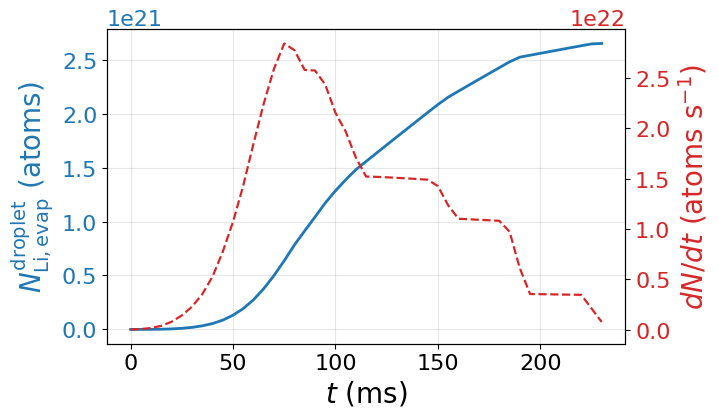

In [141]:
evap_csv = Path("output/droplet_evap_total.csv")
arr = np.loadtxt(evap_csv, comments="#")
step  = arr[:, 0]
n_cum = arr[:, 1]

dt   = 5.0e-5
t_s  = step * dt
rate = np.gradient(n_cum, t_s)

fig, ax1 = plt.subplots(figsize=(7.5, 4.5))
ax1.plot(t_s * 1e3, n_cum, lw=2, color="C0", label="cumulative")
ax1.set_xlabel(r"$t$ (ms)")
ax1.set_ylabel(r"$N_\mathrm{Li,evap}^\mathrm{droplet}$ (atoms)", color="C0")
ax1.tick_params(axis="y", labelcolor="C0")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(t_s * 1e3, rate, lw=1.6, color="C3", ls="--", label="rate")
ax2.set_ylabel(r"$dN/dt$ (atoms s$^{-1}$)", color="C3")
ax2.tick_params(axis="y", labelcolor="C3")

print(f"total Li atoms evaporated from droplets: {n_cum[-1]:.3e}")
print(f"peak rate: {rate.max():.3e} atoms/s")
plt.tight_layout(); plt.show()
